# 01 — Dataset Exploration

**Prerequisites (run once via scripts before opening this notebook):**
```bash
python scripts/download_dataset.py       # downloads val2019 + JSONs
python scripts/prepare_yolo_dataset.py   # creates 80/10/10 YOLO split
```

This notebook is for analysis and presentation only — no downloads, no data writing.

Covers:
1. Dataset statistics
2. Difficulty level distribution
3. Annotation density
4. Top-30 SKU frequency
5. Sample scene images
6. Why train2019 is excluded
7. Why 80/10/10 split

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'matplotlib', 'Pillow', '-q'], check=True)
print('Dependencies ready ✓')

Dependencies ready ✓


In [2]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIGS = ROOT / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

# Load rpc_root from pointer written by download script
pointer = ROOT / 'data' / 'raw' / 'rpc_kagglehub_path.txt'
if not pointer.exists():
    raise FileNotFoundError('Run scripts/download_dataset.py first.')
rpc_root = Path(pointer.read_text().strip())

print('Root:    ', ROOT)
print('rpc_root:', rpc_root)
print('val2019: ', (rpc_root / 'val2019').exists())

Root:     /mnt/custom-file-systems/efs/fs-02d21030926db1df2_fsap-0de09adebc257215c
rpc_root: /mnt/custom-file-systems/efs/fs-02d21030926db1df2_fsap-0de09adebc257215c/data/raw/rpc/retail_product_checkout
val2019:  True


## 1. Dataset Statistics

In [3]:
def find_json(root, name):
    for p in [root / name, root / 'retail_product_checkout' / name]:
        if p.exists():
            return p
    return next(root.glob(f'**/{name}'))

train_data = json.loads(find_json(rpc_root, 'instances_train2019.json').read_text())
val_data   = json.loads(find_json(rpc_root, 'instances_val2019.json').read_text())
test_data  = json.loads(find_json(rpc_root, 'instances_test2019.json').read_text())

print(f"{'Split':<12} {'Images':>8} {'Annotations':>12} {'Avg ann/img':>12} {'Has levels':>12}")
print('-' * 58)
for name, d in [('train2019', train_data), ('val2019', val_data), ('test2019', test_data)]:
    imgs  = len(d['images'])
    anns  = len(d['annotations'])
    has_l = 'level' in d['images'][0]
    print(f"{name:<12} {imgs:>8,} {anns:>12,} {anns/imgs:>12.1f} {str(has_l):>12}")
print(f'\nTotal categories: {len(val_data["categories"])}')

Split          Images  Annotations  Avg ann/img   Has levels
----------------------------------------------------------
train2019      53,739       53,739          1.0        False
val2019         6,000       73,602         12.3         True
test2019       24,000      294,333         12.3         True

Total categories: 200


## 2. Difficulty Level Distribution

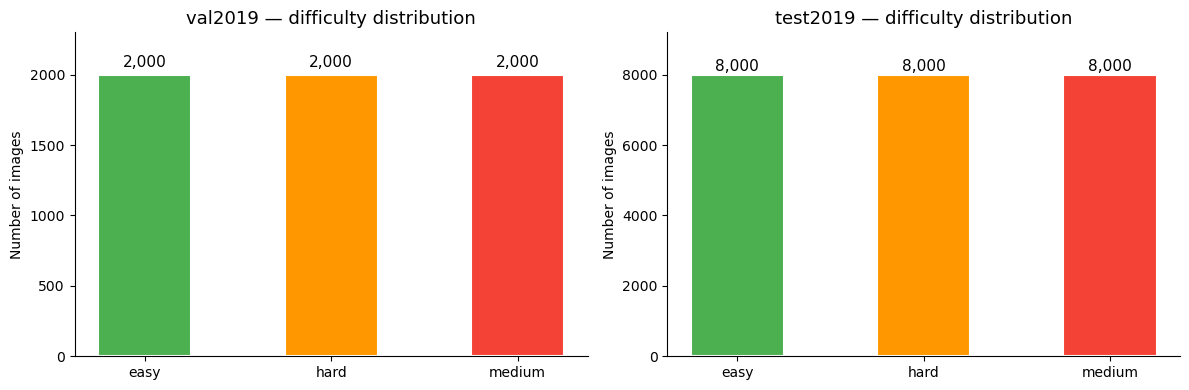

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (split_name, data) in zip(axes, [('val2019', val_data), ('test2019', test_data)]):
    levels = Counter(img.get('level', 'unknown') for img in data['images'])
    labels, counts = zip(*sorted(levels.items()))
    bars = ax.bar(labels, counts, color=['#4caf50', '#ff9800', '#f44336'],
                  width=0.5, edgecolor='white', linewidth=1.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f'{count:,}', ha='center', va='bottom', fontsize=11)
    ax.set_title(f'{split_name} — difficulty distribution', fontsize=13)
    ax.set_ylabel('Number of images')
    ax.set_ylim(0, max(counts) * 1.15)
    ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / 'fig_level_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Annotation Density per Image

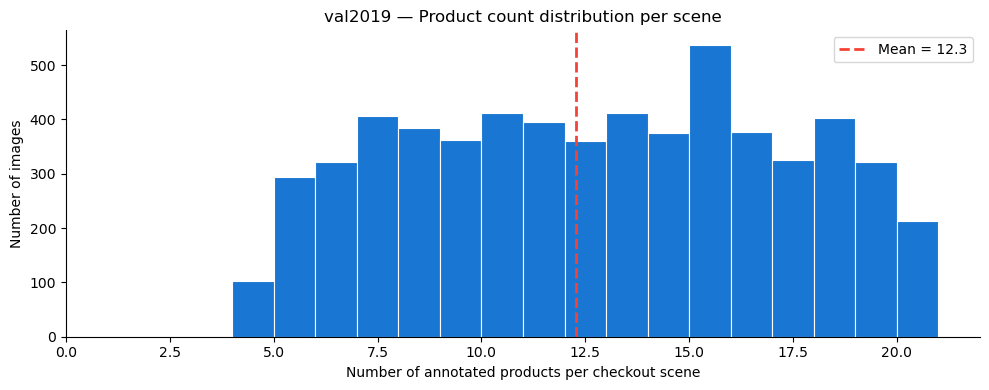

Min: 4  Max: 20  Mean: 12.3


In [5]:
counts_per_img = list(Counter(a['image_id'] for a in val_data['annotations']).values())
mean_val = sum(counts_per_img) / len(counts_per_img)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(counts_per_img, bins=range(1, max(counts_per_img)+2),
        color='#1976d2', edgecolor='white', linewidth=0.8)
ax.axvline(mean_val, color='#f44336', linestyle='--', linewidth=2,
           label=f'Mean = {mean_val:.1f}')
ax.set_xlabel('Number of annotated products per checkout scene')
ax.set_ylabel('Number of images')
ax.set_title('val2019 — Product count distribution per scene')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / 'fig_ann_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Min: {min(counts_per_img)}  Max: {max(counts_per_img)}  Mean: {mean_val:.1f}')

## 4. Top-30 SKU Frequency

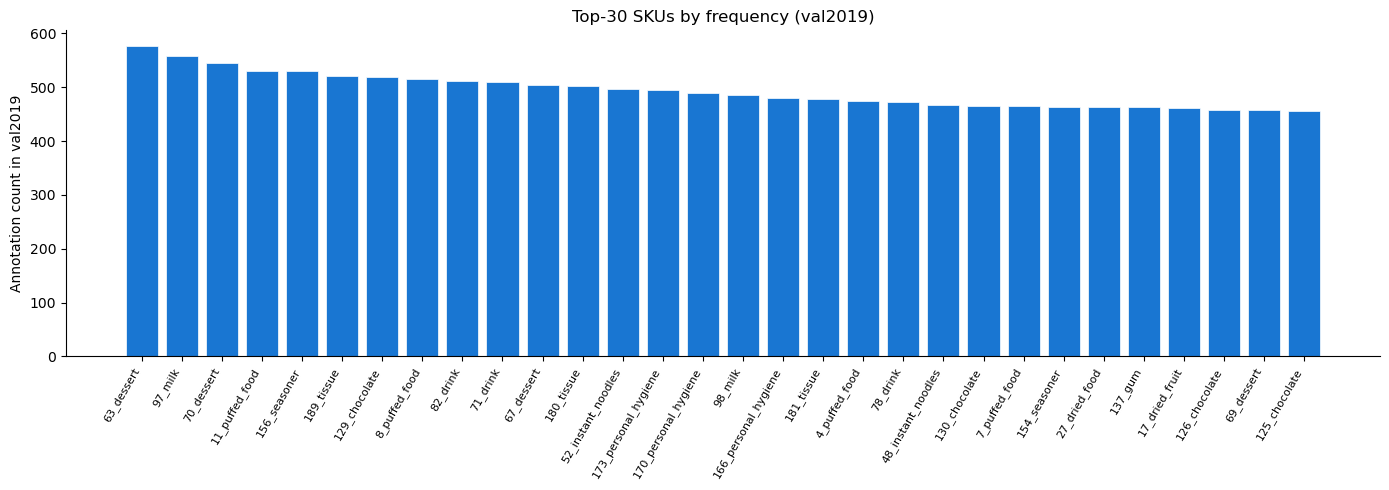

In [6]:
cat_id_to_name = {c['id']: c['name'] for c in val_data['categories']}
top30 = Counter(a['category_id'] for a in val_data['annotations']).most_common(30)
names30  = [cat_id_to_name[cid] for cid, _ in top30]
counts30 = [cnt for _, cnt in top30]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(30), counts30, color='#1976d2', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(30))
ax.set_xticklabels(names30, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Annotation count in val2019')
ax.set_title('Top-30 SKUs by frequency (val2019)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(FIGS / 'fig_top30_sku.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Sample Scene Images

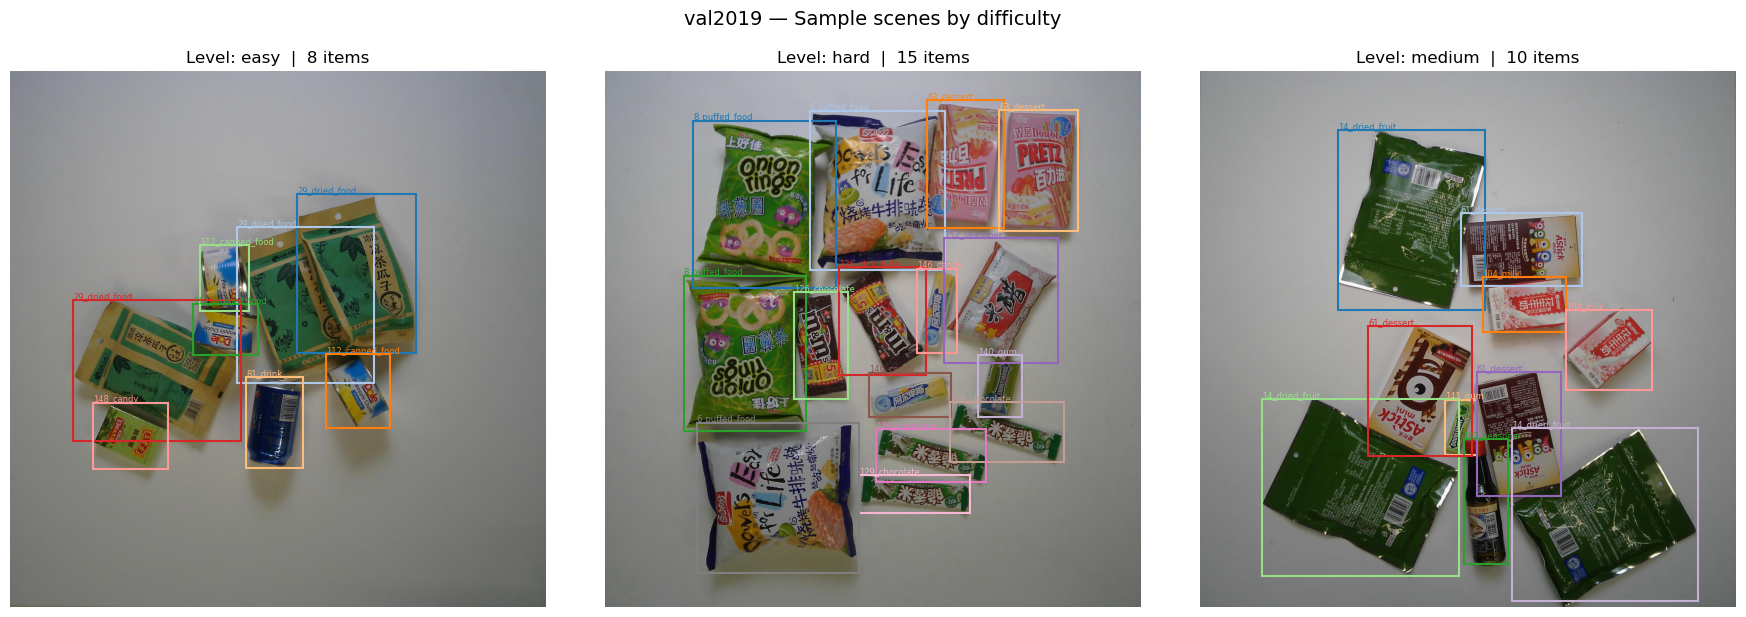

In [7]:
def find_img_dir(root, name):
    for p in [root / name, root / 'retail_product_checkout' / name]:
        if p.exists():
            return p
    return None

val_img_dir = find_img_dir(rpc_root, 'val2019')

if val_img_dir is None:
    print('val2019 images not found — skipped.')
else:
    ann_by_img = defaultdict(list)
    for a in val_data['annotations']:
        ann_by_img[a['image_id']].append(a)

    by_level = defaultdict(list)
    for img in val_data['images']:
        by_level[img.get('level', 'unknown')].append(img)

    rng = random.Random(42)
    samples = {lvl: rng.choice(imgs) for lvl, imgs in sorted(by_level.items())}
    cmap = plt.get_cmap('tab20')

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, (level, meta) in zip(axes, samples.items()):
        img_path = val_img_dir / meta['file_name']
        if not img_path.exists():
            ax.set_title(f'{level} — not found'); ax.axis('off'); continue
        ax.imshow(Image.open(img_path).convert('RGB'))
        for i, ann in enumerate(ann_by_img[meta['id']]):
            x, y, w, h = ann['bbox']
            ax.add_patch(patches.Rectangle((x, y), w, h, linewidth=1.5,
                         edgecolor=cmap(i % 20), facecolor='none'))
            ax.text(x, y-3, cat_id_to_name.get(ann['category_id'], ''),
                    fontsize=6, color=cmap(i % 20))
        ax.set_title(f'Level: {level}  |  {len(ann_by_img[meta["id"]])} items')
        ax.axis('off')
    plt.suptitle('val2019 — Sample scenes by difficulty', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(FIGS / 'fig_sample_scenes.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Why train2019 Is Not Used

In [8]:
train_per_img = Counter(a['image_id'] for a in train_data['annotations'])
assert all(v == 1 for v in train_per_img.values())

print(f"{'Subset':<12} {'Images':>8} {'Avg items/image':>16} {'Scene type'}")
print('-' * 60)
print(f"{'train2019':<12} {len(train_data['images']):>8,} {'1.0':>16}   isolated single-product")
avg = len(val_data['annotations']) / len(val_data['images'])
print(f"{'val2019':<12} {len(val_data['images']):>8,} {avg:>16.1f}   cluttered checkout-scene")
print()
print('Conclusion: train2019 contains isolated product photos unsuitable for scene detection.')
print('val2019 checkout scenes were used as training source, split 80/10/10 by difficulty level.')

Subset         Images  Avg items/image Scene type
------------------------------------------------------------
train2019      53,739              1.0   isolated single-product
val2019         6,000             12.3   cluttered checkout-scene

Conclusion: train2019 contains isolated product photos unsuitable for scene detection.
val2019 checkout scenes were used as training source, split 80/10/10 by difficulty level.


## 7. Why 80/10/10 Instead of 70/15/15?

With only **6,000 checkout scenes** and **200 product classes**, the priority is maximising training data:

| Split | Train | Val | Test |
|-------|------:|----:|-----:|
| 70/15/15 | 4,200 | 900 | 900 |
| **80/10/10** | **4,800** | **600** | **600** |

**+600 training images** is a meaningful gain (~14%) for a 200-class detector — each extra scene contributes rare SKU appearances that help low-frequency classes generalise.

The validation and test sets shrink from 900 → 600, but 600 images (200 per difficulty level) is still large enough to produce stable mAP estimates.

The stratified split by difficulty level ensures every subset sees the full range of scene complexity.

## 8. Actual Split Results — Stratification Verified

In [9]:
import random
from collections import defaultdict

def stratified_split(images, seed=42):
    by_level = defaultdict(list)
    for img in images:
        by_level[img.get('level', 'unknown')].append(img)
    rng = random.Random(seed)
    train, val, test = [], [], []
    for lvl_imgs in by_level.values():
        rng.shuffle(lvl_imgs)
        n = len(lvl_imgs)
        n_val  = max(1, round(n * 0.10))
        n_test = max(1, round(n * 0.10))
        test.extend(lvl_imgs[:n_test])
        val.extend(lvl_imgs[n_test: n_test + n_val])
        train.extend(lvl_imgs[n_test + n_val:])
    return train, val, test

train_imgs, val_imgs, test_imgs = stratified_split(val_data['images'])

def level_counts(imgs):
    c = Counter(img.get('level', 'unknown') for img in imgs)
    return c.get('easy', 0), c.get('medium', 0), c.get('hard', 0)

print(f"{'Split':<8} {'Images':>7} {'Easy':>7} {'Medium':>8} {'Hard':>7}")
print('-' * 42)
for name, imgs in [('Train', train_imgs), ('Val', val_imgs), ('Test', test_imgs)]:
    e, m, h = level_counts(imgs)
    print(f"{name:<8} {len(imgs):>7} {e:>7} {m:>8} {h:>7}")
print()
print('✓ Each split contains equal proportions of easy / medium / hard scenes (stratified).')

Split     Images    Easy   Medium    Hard
------------------------------------------
Train       4800    1600     1600    1600
Val          600     200      200     200
Test         600     200      200     200

✓ Each split contains equal proportions of easy / medium / hard scenes (stratified).


## 9. YOLO Data Pipeline Evidence

`prepare_yolo_dataset.py` converts each COCO bounding box to YOLO normalised format and writes one `.txt` label file per image.  
This cell reconstructs a live example from real val2019 annotations to confirm the pipeline produced valid training labels.

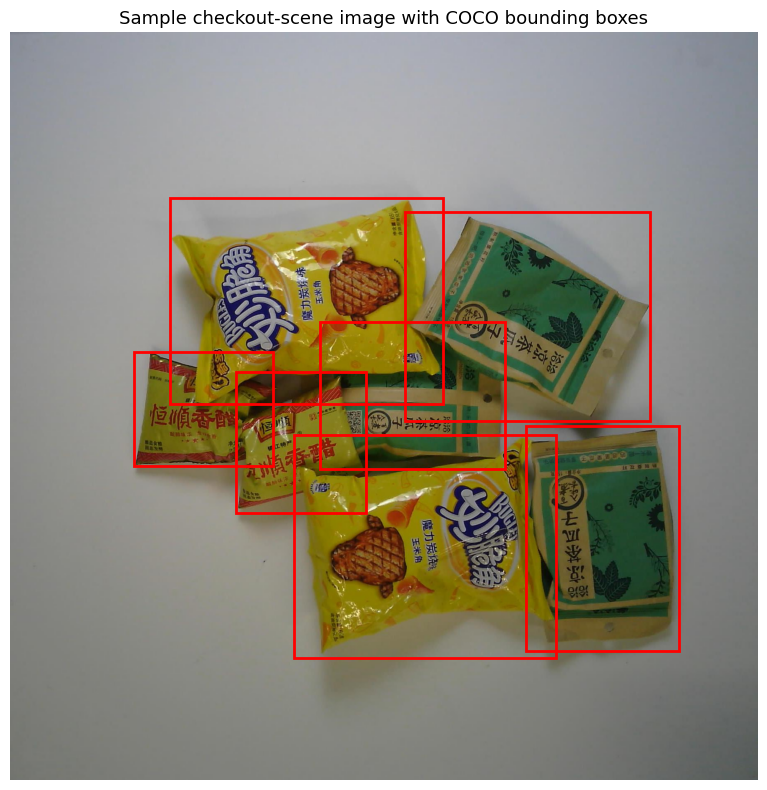

Image file: 20180829-13-29-41-1321.jpg
Label file: train/labels/20180829-13-29-41-1321.txt
Image size: 1805 × 1805   |   Annotations: 7

Original COCO annotations:
Format:  <category_id>  [x, y, width, height]   (pixel coordinates)
----------------------------------------------------------------------
5             [386.0, 399.84, 658.32, 496.82]
29            [953.57, 433.68, 590.64, 504.51]
29            [747.46, 699.77, 447.6, 353.77]
153           [544.42, 819.75, 313.78, 339.93]
153           [299.86, 772.07, 333.77, 273.79]
5             [684.39, 970.48, 633.71, 538.34]
29            [1244.27, 948.95, 370.69, 544.5]

Converted YOLO label rows:
Format:  <class_id>  <x_center>  <y_center>  <width>  <height>   (all normalised 0–1)
----------------------------------------------------------------------
4 0.396211 0.359141 0.364720 0.275247
28 0.691906 0.380019 0.327224 0.279507
28 0.538094 0.485681 0.247978 0.195994
152 0.388537 0.548319 0.173839 0.188327
152 0.258584 0.503582 0.18491

In [19]:
from pathlib import Path
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def find_img_dir(root, name):
    for p in [root / name, root / 'retail_product_checkout' / name]:
        if p.exists():
            return p
    return None

def coco_to_yolo(bbox, img_w, img_h):
    x, y, w, h = bbox
    return (
        (x + w / 2) / img_w,
        (y + h / 2) / img_h,
        w / img_w,
        h / img_h,
    )

def stratified_split(images, seed=42):
    import random
    by_level = defaultdict(list)
    for img in images:
        by_level[img.get("level", "unknown")].append(img)

    rng = random.Random(seed)
    train, val, test = [], [], []

    for level in sorted(by_level):
        lvl_imgs = by_level[level][:]
        rng.shuffle(lvl_imgs)
        n = len(lvl_imgs)
        n_val = max(1, round(n * 0.10))
        n_test = max(1, round(n * 0.10))

        test.extend(lvl_imgs[:n_test])
        val.extend(lvl_imgs[n_test:n_test + n_val])
        train.extend(lvl_imgs[n_test + n_val:])

    return train, val, test

# ---------- Build annotation index ----------
ann_by_img = defaultdict(list)
for ann in val_data["annotations"]:
    ann_by_img[ann["image_id"]].append(ann)

cat_id_to_idx = {c["id"]: i for i, c in enumerate(val_data["categories"])}
cat_id_to_name = {c["id"]: c["name"] for c in val_data["categories"]}

# ---------- Recreate the same split ----------
train_imgs, val_imgs_split, test_imgs_split = stratified_split(val_data["images"], seed=42)

# Pick one real training image with annotations
sample_img = next(img for img in train_imgs if ann_by_img.get(img["id"]))
sample_anns = ann_by_img[sample_img["id"]]

# ---------- Locate the actual image ----------
val2019_dir = find_img_dir(rpc_root, "val2019")
img_path = val2019_dir / sample_img["file_name"]

# ---------- Show original image with COCO bounding boxes ----------
img = Image.open(img_path)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)

for ann in sample_anns:
    x, y, w, h = ann["bbox"]
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=2,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

ax.set_title(f"Sample checkout-scene image with COCO bounding boxes", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

# ---------- Build the YOLO label lines for this image ----------
label_lines = []
for ann in sample_anns:
    cls_idx = cat_id_to_idx[ann["category_id"]]
    cx, cy, bw, bh = coco_to_yolo(ann["bbox"], sample_img["width"], sample_img["height"])
    label_lines.append(f"{cls_idx} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

label_rel_path = f"train/labels/{Path(sample_img['file_name']).stem}.txt"

print(f"Image file: {sample_img['file_name']}")
print(f"Label file: {label_rel_path}")
print(f"Image size: {sample_img['width']} × {sample_img['height']}   |   Annotations: {len(sample_anns)}")
print()

print("Original COCO annotations:")
print("Format:  <category_id>  [x, y, width, height]   (pixel coordinates)")
print("-" * 70)
for ann in sample_anns[:8]:
    print(f"{ann['category_id']:<13} {ann['bbox']}")
if len(sample_anns) > 8:
    print(f"... ({len(sample_anns) - 8} more COCO annotations)")
print()

print("Converted YOLO label rows:")
print("Format:  <class_id>  <x_center>  <y_center>  <width>  <height>   (all normalised 0–1)")
print("-" * 70)
for line in label_lines[:8]:
    print(line)
if len(label_lines) > 8:
    print(f"... ({len(label_lines) - 8} more YOLO rows)")
print()

print(f"✓ The red boxes above come from the original COCO annotations, which were then converted into YOLO training labels.")

## 10. Product Catalogue — 200 SKU Classes

`configs/products.json` maps every YOLO class index to a SKU name, barcode, display name, and product category.  
This confirms that all 200 classes have rich metadata and that the model's output can be directly converted into an itemised receipt.

In [12]:
products_path = ROOT / 'configs' / 'products.json'
if products_path.exists():
    products = json.loads(products_path.read_text(encoding='utf-8'))
    entries = sorted(products.values(), key=lambda e: e['yolo_id'])
    print(f"Total SKU classes: {len(products)}")
    print()
    header = f"{'YOLO ID':>8}  {'SKU key':<22}  {'Category':<18}  {'Display name'}"
    print(header)
    print('-' * len(header))
    for entry in entries[:8]:
        print(f"{entry['yolo_id']:>8}  {entry['sku_name']:<22}  {entry['sku_class']:<18}  {entry['display_name']}")
    print(f"  ... ({len(products) - 8} more SKUs)")
    print()
    cats = Counter(e['sku_class'] for e in products.values())
    print(f"Product categories ({len(cats)} total):")
    for cat, cnt in sorted(cats.items(), key=lambda x: -x[1])[:10]:
        print(f"  {cat:<22} {cnt:>3} SKUs")
    if len(cats) > 10:
        print(f"  ... ({len(cats) - 10} more categories)")
    print()
    print("✓ products.json confirmed: 200 SKU classes with barcodes, display names, and category labels.")
else:
    # products.json lives in the webapp; on SageMaker derive equivalent info from COCO annotations
    cats_sorted = sorted(val_data['categories'], key=lambda c: c['id'])
    print(f"(products.json not present — deriving from COCO annotations)")
    print(f"Total SKU classes: {len(cats_sorted)}")
    print()
    header = f"{'YOLO ID':>8}  {'category_id':>12}  {'name'}"
    print(header)
    print('-' * 50)
    for i, cat in enumerate(cats_sorted[:8]):
        print(f"{i:>8}  {cat['id']:>12}  {cat['name']}")
    print(f"  ... ({len(cats_sorted) - 8} more SKUs)")
    print()
    print(f"✓ {len(cats_sorted)} unique SKU classes confirmed in val2019 annotations.")

(products.json not present — deriving from COCO annotations)
Total SKU classes: 200

 YOLO ID   category_id  name
--------------------------------------------------
       0             1  1_puffed_food
       1             2  2_puffed_food
       2             3  3_puffed_food
       3             4  4_puffed_food
       4             5  5_puffed_food
       5             6  6_puffed_food
       6             7  7_puffed_food
       7             8  8_puffed_food
  ... (192 more SKUs)

✓ 200 unique SKU classes confirmed in val2019 annotations.
